In [1]:
import pandas as pd
import numpy as np
import os
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sys
import scipy.stats as stats
import arviz as az

sys.path.append(os.path.abspath('..'))
import utils
import mdp_utils
import process_data as dp
import bayesian_analysis as ba

%load_ext autoreload
%autoreload 2

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
Failed to read module file 'C:\Python311\Lib\functools.py' for module 'functools': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\shirl\Documents\Studie\2025-2026\Thesis\personalized-coping-challenges\.venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\shirl\Documents\Studie\2025-2026\Thesis\personalized-coping-challenges\.venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Python311\Lib\importlib\_

In [2]:
state_features = ['TIR', 'TIME_Q', 'GOOD']
feature_names = ['Tiredness', 'Time available', 'Perceived Usefulness']

action_col = "joint_cluster"

cluster_col = 'cluster_all'
cluster_vars = ['likedness', 'usefulness', 'difficulty']
cluster_cols = [col + '_cluster' for col in cluster_vars]

reward_cols = ["r_likedness", "r_usefulness", "r_diversity", "r_expert", "r_return"]
obj_names = ["Fun", "Perceived Usefulness", "Diversity", "Expert Usefulness", "Return Willingness"]

evaluation_cols = ["time_spent", "likedness", "usefulness", "PAY_next", "expert_score", "diversity"]
evaluation_names = ["Time Spent", "Likedness", "Perceived Usefulness", "Return Willingness", "Expert Usefulness", "Diversity"]

NUM_CATEGORIES = 4
NUM_FEATURES = len(state_features)
NUM_VALS_PER_FEATURE = [2, 2, 3]
NUM_USER_STATES = np.prod(NUM_VALS_PER_FEATURE)
NUM_CLUSTERS = 3
MAX_COUNT = 0
NUM_COUNT_STATES = (MAX_COUNT+1)**NUM_CATEGORIES
NUM_STATES = NUM_USER_STATES * NUM_COUNT_STATES 
NUM_ACTIONS = NUM_CLUSTERS * 2  # Within each cluster we either recommend a 'least favorite' coping category or a familiar one
NUM_OBJECTIVES = len(reward_cols)

In [3]:
data_folder = 'C:\\Users\\shirl\\Documents\\Studie\\2025-2026\\Thesis\\personalized-coping-challenges\\data\\'
results_folder = 'C:\\Users\\shirl\\Documents\\Studie\\2025-2026\\Thesis\\personalized-coping-challenges\\results\\'

# Load data
action_data = pd.read_csv(os.path.join(data_folder, 'challenge_info.csv'))
samples = pd.read_csv(os.path.join(data_folder, 'processed_samples.csv'))

actions_clustered, _, _ = dp.cluster_actions(action_data, cluster_vars, num_clusters=NUM_CLUSTERS)
# actions_clustered['cat_diff_cluster'] = actions_clustered.groupby(['category', 'expert_score']).ngroup()

df, initial_distribution, mapping = dp.process_samples(samples, actions_clustered, state_features, NUM_VALS_PER_FEATURE, action_col, cluster_col, MAX_COUNT, NUM_CLUSTERS)
df.head(50)

Number of samples after processing: 3111


,user_id,day_number,TIR,MOT,GOOD,TIME_Q,PAY,TIR_next,MOT_next,GOOD_next,...,c_idx,s_idx,sp_idx,r_time,r_difficulty,r_likedness,r_usefulness,r_return,r_expert,joint_cluster
0,1111591584,1,5,6,6,3,6,4.0,4.0,5.0,...,0,8,1,0.000000,0.000000,0.000000,0.000000,0.666667,0.00,5
1,1111591584,2,4,4,5,4,5,6.0,2.0,5.0,...,0,1,7,0.983333,0.545455,0.909091,1.000000,0.833333,0.66,2
2,1111591584,3,6,2,5,3,6,4.0,5.0,5.0,...,0,7,4,0.993333,0.454545,0.818182,0.714286,0.833333,1.00,1
3,1111591584,4,4,5,5,5,6,5.0,5.0,6.0,...,0,4,8,0.000000,0.000000,0.000000,0.000000,0.833333,0.00,5
4,1111591584,5,5,5,6,4,6,3.0,4.0,6.0,...,0,8,2,0.990000,0.363636,0.909091,1.000000,0.833333,0.66,1
5,1111591584,16,4,4,6,3,6,3.0,3.0,6.0,...,0,2,2,0.993333,0.545455,0.818182,0.857143,0.833333,0.66,1
6,1139851159,1,4,5,5,4,4,2.0,7.0,6.0,...,0,1,5,0.966667,0.818182,0.909091,1.142857,0.666667,0.33,1
7,1178274181,1,2,7,5,6,7,3.0,2.0,6.0,...,0,4,2,0.996667,0.909091,0.636364,0.285714,1.000000,0.66,1
8,1178274181,2,3,2,6,2,7,5.0,1.0,4.0,...,0,2,9,0.996667,0.272727,0.181818,0.285714,1.000000,0.66,2
9,1178274181,3,5,1,4,5,7,3.0,6.0,4.0,...,0,9,3,0.996667,0.909091,0.727273,0.428571,1.000000,0.33,1


In [4]:
stochastic_outcomes = ["likedness", "usefulness", "difficulty", "PAY_next"]

In [5]:
def evaluate_dynamics(test_df, P_comp, R, P, R_action_only, P_comp_action_only, p_comp_overall, R_outcomes, R_outcomes_action_only, R_probs_diff_global):
    data_list = []
    for t in range(len(test_df)):
        user_row = {"t": t}
        # True values
        s_t = test_df.iloc[t]['s_idx']
        c_t = test_df.iloc[t]['c_idx']
        a_t = test_df.iloc[t][action_col]
        s_t_next = test_df.iloc[t]['sp_idx']
        r_t = test_df.iloc[t][reward_cols].values
        completed = test_df.iloc[t]['completed']

        # Reward predictions
        r_pred = R[s_t, c_t, a_t]
        r_pred_action_only = R_action_only[a_t]
        mse_reward = np.mean((r_t - r_pred)**2)
        l1_reward = np.abs(r_t - r_pred)
        
        for i, obj in enumerate(reward_cols):
            user_row[f'{obj}_l1_error'] = l1_reward[i]
            user_row[f'{obj}_l1_error_action_only'] = np.abs(r_t[i] - r_pred_action_only[i])

        # Next state likelihood
        P_s_t_next = P[s_t, a_t, s_t_next]
        user_row['next_state_likelihood'] = P_s_t_next
        user_row['equal_state'] = (s_t_next == s_t)
        user_row['s_idx'] = s_t

        # Completion likelihood
        P_comp_pred = P_comp[s_t, a_t]
        P_comp_pred_action_only = P_comp_action_only[a_t]
        user_row['completion_likelihood'] = P_comp_pred if completed else (1 - P_comp_pred)
        user_row['completion_likelihood_action_only'] = P_comp_pred_action_only if completed else (1 - P_comp_pred_action_only)
        user_row['completion_likelihood_overall'] = p_comp_overall if completed else (1 - p_comp_overall)
        user_row['completed'] = completed

        for outcome in stochastic_outcomes:
            outcome_value_t = test_df.iloc[t][outcome]
            if outcome == "PAY_next":
                outcome_value_t = outcome_value_t - 1  # convert 1-7 to 0-6 for indexing, for other outcomes the values are already 0-indexed, where 0 is equal to the non-completion probability
            if pd.isna(outcome_value_t):
                continue  # Skip if outcome value is missing
            R_outcome = R_outcomes[outcome]
            user_row[f'{outcome}_likelihood'] = R_outcome[s_t, a_t, int(outcome_value_t)]

            R_outcome_action_only = R_outcomes_action_only[outcome]
            outcome_likelihood_action_only = R_outcome_action_only[a_t, int(outcome_value_t)]
            user_row[f'{outcome}_likelihood_action_only'] = outcome_likelihood_action_only

            R_outcome_global = R_probs_diff_global[outcome]
            user_row[f'{outcome}_likelihood_global'] = R_outcome_global[int(outcome_value_t)]
        data_list.append(user_row)
        
    return pd.DataFrame(data_list)

In [23]:
all_users = df['user_id'].unique()
print("Number of users:", len(all_users))

lam = 1

all_user_results = []
for test_user in all_users:

    train_df = df[df['user_id'] != test_user]
    test_df = df[df['user_id'] == test_user]
    
    P_comp = mdp_utils.compute_completion_probabilities(train_df, NUM_USER_STATES, NUM_ACTIONS, action_col)
    R = mdp_utils.compute_rewards(train_df, P_comp, NUM_USER_STATES, NUM_COUNT_STATES, NUM_ACTIONS, NUM_OBJECTIVES, reward_cols, action_col, mapping)
    R_action_only = mdp_utils.compute_avg_rewards(train_df, NUM_ACTIONS, action_col, reward_cols)
    
    P = mdp_utils.compute_transition_probabilities(train_df, NUM_USER_STATES, NUM_ACTIONS, action_col, alpha=0)
    P_return = mdp_utils.compute_return_probabilities(train_df)
    
    P_comp_action_only = mdp_utils.compute_completion_probabilities_action_only(
        train_df, NUM_ACTIONS, action_col
    )

    p_comp_overall = train_df['completed'].mean()

    R_outcomes = {o: mdp_utils.compute_reward_probabilities(train_df, o, NUM_USER_STATES, NUM_ACTIONS, action_col, lam=lam) for o in stochastic_outcomes}

    R_outcomes_action_only = {o: mdp_utils.compute_reward_probabilities_action_only(train_df, o, NUM_ACTIONS, action_col, lam=lam) for o in stochastic_outcomes}
        
    R_probs_diff_global = {o: mdp_utils.compute_reward_probabilities_global(train_df, o) for o in stochastic_outcomes}
    
    result_df = evaluate_dynamics(test_df, P_comp, R, P, R_action_only, P_comp_action_only, p_comp_overall, 
                                  R_outcomes, R_outcomes_action_only, R_probs_diff_global)
    result_df['user_id'] = test_user
    all_user_results.append(result_df)
    
combined_results = pd.concat(all_user_results, ignore_index=True)

Number of users: 309


In [24]:
print("\nMean L1 errors by objective:")
l1_cols = [col + '_l1_error' for col in reward_cols]
print(combined_results[l1_cols].mean())

print("\nComparison of state-action vs action-only:")
for obj in reward_cols:
    sa_mean = combined_results[f'{obj}_l1_error'].mean()
    ao_mean = combined_results[f'{obj}_l1_error_action_only'].mean()
    print(f"{obj}: State-Action={sa_mean:.4f}, Action-Only={ao_mean:.4f}, Diff={sa_mean - ao_mean:.4f}")


Mean L1 errors by objective:
r_likedness_l1_error     0.259874
r_usefulness_l1_error    0.262810
r_diversity_l1_error     0.000000
r_expert_l1_error        0.276738
r_return_l1_error        0.192984
dtype: float64

Comparison of state-action vs action-only:
r_likedness: State-Action=0.2599, Action-Only=0.2623, Diff=-0.0024
r_usefulness: State-Action=0.2628, Action-Only=0.2645, Diff=-0.0016
r_diversity: State-Action=0.0000, Action-Only=0.0000, Diff=0.0000
r_expert: State-Action=0.2767, Action-Only=0.2743, Diff=0.0024
r_return: State-Action=0.1930, Action-Only=0.2016, Diff=-0.0086


### Reward function evaluation
To evaluate our learned reward function, we compare it against using only the action to predict the reward.

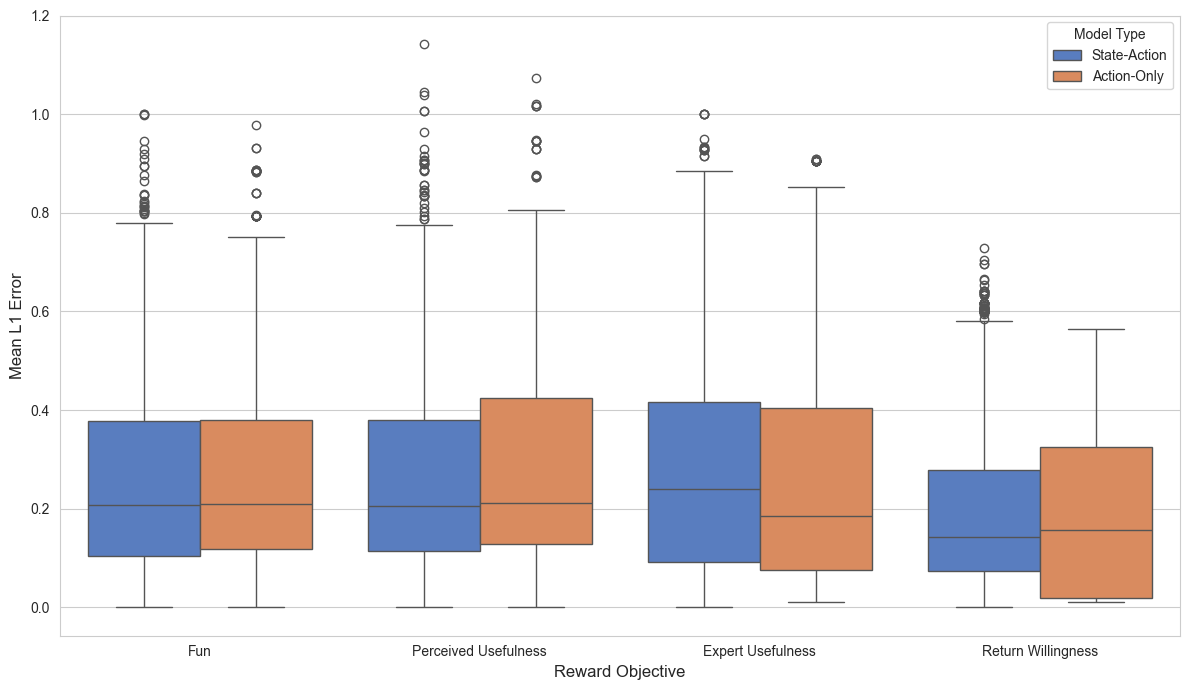

In [25]:
# Group by user for paired testing
for obj in reward_cols:
    # A negative difference means the State-Action model had LOWER error (Better)
    combined_results[f'raw_diff_{obj}'] = (
        combined_results[f'{obj}_l1_error'] - 
        combined_results[f'{obj}_l1_error_action_only']
    )

# Group by user to get the average "Advantage" of the state-based model per person
user_summaries = combined_results.groupby('user_id').agg({
    f'raw_diff_{obj}': 'mean' for obj in reward_cols
}).reset_index()

# plot mean l1 error per objective for state-action vs action-only
plot_records = []
for obj, obj_name in zip(reward_cols, obj_names):
    if obj == "r_diversity":
        continue
    # Get values for State-Action
    state_action = combined_results[f'{obj}_l1_error']
    for err in state_action:
        plot_records.append({'Objective': obj_name, 'L1 Error': err, 'Model': 'State-Action'})
    
    # Get values for Action-Only
    action_only = combined_results[f'{obj}_l1_error_action_only']
    for err in action_only:
        plot_records.append({'Objective': obj_name, 'L1 Error': err, 'Model': 'Action-Only'})

viz_df = pd.DataFrame(plot_records)

# 2. Create the plot
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Use a barplot with 95% confidence intervals (black lines)
ax = sns.boxplot(
    data=viz_df, 
    x='Objective', 
    y='L1 Error', 
    hue='Model', 
    palette="muted",
    # capsize=.05,
    # errorbar=('ci', 95)
)

# plt.title('Predictive Performance: State-Action vs. Action-Only Reward Models', fontsize=14)
plt.ylabel('Mean L1 Error', fontsize=12)
plt.xlabel('Reward Objective', fontsize=12)
plt.legend(title='Model Type', frameon=True)

plt.savefig(results_folder + "figures/reward_model_comparison.svg", bbox_inches='tight')
plt.tight_layout()
plt.show()

In [26]:
for obj, obj_name in zip(reward_cols, obj_names):
    if obj == "r_diversity":
        continue  # Skip diversity for this analysis, since it is deterministic
    combined_results[f'{obj}_improvement'] = combined_results[f'{obj}_l1_error_action_only'] - combined_results[f'{obj}_l1_error']
    user_diffs = combined_results.groupby('user_id')[f'{obj}_improvement'].mean().values
    print(f"\n{obj_name}:")
    ba.paired_t_test(user_diffs)



Fun:
              mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
improvement  0.003  0.001     0.001      0.006      0.000    0.000  5236.160   
effect_size  0.164  0.062     0.046      0.286      0.001    0.001  4776.429   

             ess_tail  r_hat  
improvement  3423.073    1.0  
effect_size  3339.419    1.0  
P(improvement > 0): 0.9975
P(Effect Size > 0.1): 0.8468
P(Effect Size > 0.2): 0.2890
P(Effect Size > 0.3): 0.0127

Perceived Usefulness:
              mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
improvement  0.003  0.001    -0.000      0.006      0.000    0.000  4423.105   
effect_size  0.111  0.061    -0.002      0.235      0.001    0.001  4331.017   

             ess_tail  r_hat  
improvement   2978.47    1.0  
effect_size   2978.47    1.0  
P(improvement > 0): 0.9688
P(Effect Size > 0.1): 0.5743
P(Effect Size > 0.2): 0.0717
P(Effect Size > 0.3): 0.0008

Expert Usefulness:
              mean     sd  hdi_2.5%  hdi_97.5%  mcse_me

### Stochastic outcomes

C:\Users\shirl\AppData\Local\Temp\ipykernel_91152\1943692562.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Fun', 'Perceived Usefulness', 'Difficulty', 'Return Willingness'])


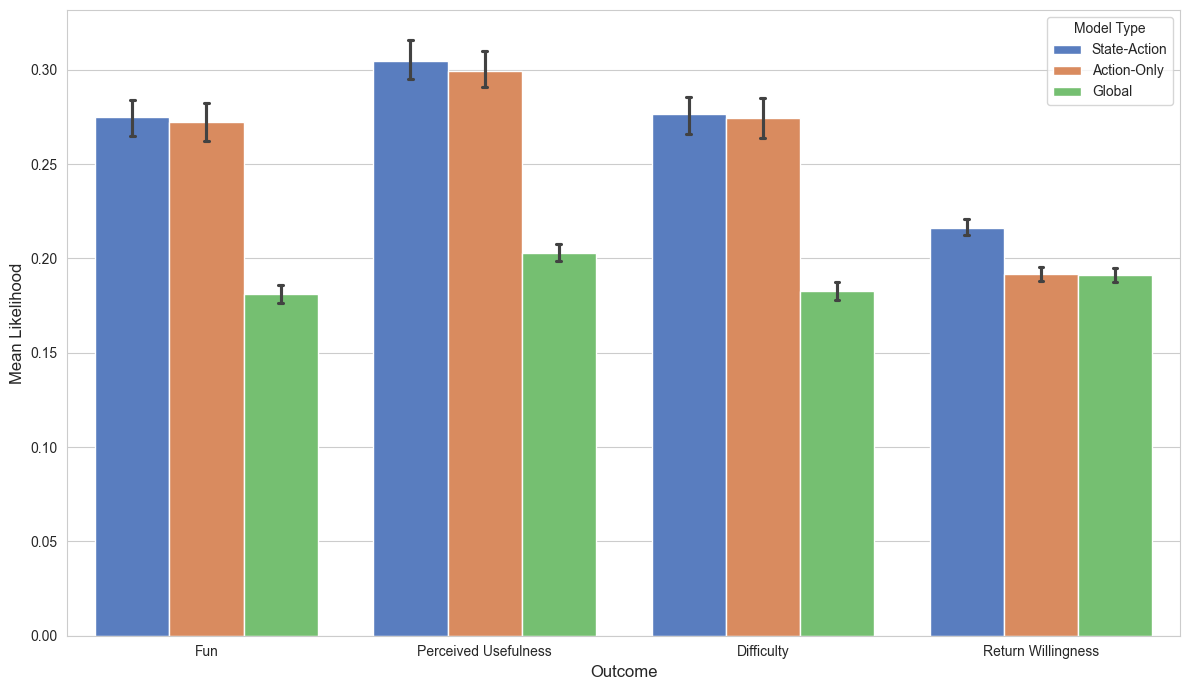

In [27]:
# plot mean likelihoods of outcomes
plot_records = []
for obj in stochastic_outcomes:
    state_action = combined_results[f'{obj}_likelihood']
    for prob in state_action:
        plot_records.append({'Outcome': obj, 'Likelihood': prob, 'Model': 'State-Action'})
    
    action_only = combined_results[f'{obj}_likelihood_action_only']
    for prob in action_only:
        plot_records.append({'Outcome': obj, 'Likelihood': prob, 'Model': 'Action-Only'})

    global_likelihoods = combined_results[f'{obj}_likelihood_global']
    for prob in global_likelihoods:
        plot_records.append({'Outcome': obj, 'Likelihood': prob, 'Model': 'Global'})

viz_df = pd.DataFrame(plot_records)

# 2. Create the plot
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Use a barplot with 95% confidence intervals (black lines)
ax = sns.barplot(
    data=viz_df, 
    x='Outcome', 
    y='Likelihood', 
    hue='Model', 
    capsize=.05,
    palette='muted',
    errorbar=('ci', 95)
)
ax.set_xticklabels(['Fun', 'Perceived Usefulness', 'Difficulty', 'Return Willingness'])

# plt.title('Predictive Performance: State-Action vs. Action-Only Reward Models', fontsize=14)
plt.ylabel('Mean Likelihood', fontsize=12)
plt.xlabel('Outcome', fontsize=12)
plt.legend(title='Model Type', frameon=True)

plt.savefig(results_folder + "figures/outcome_model_comparison.svg", bbox_inches='tight')
plt.tight_layout()
plt.show()

In [28]:
for outcome in stochastic_outcomes:
    combined_results[f'{outcome}_improvement'] = combined_results[f'{outcome}_likelihood'] - combined_results[f'{outcome}_likelihood_action_only']
    user_diffs = combined_results.groupby('user_id')[f'{outcome}_improvement'].mean().values
    print(f"\n{outcome}:")
    ba.paired_t_test(user_diffs)


likedness:
              mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
improvement  0.002  0.001     0.000      0.005      0.000    0.000  4848.827   
effect_size  0.157  0.068     0.027      0.295      0.001    0.001  4818.932   

             ess_tail  r_hat  
improvement  2903.434  0.999  
effect_size  2903.567  0.999  
P(improvement > 0): 0.9925
P(Effect Size > 0.1): 0.7967
P(Effect Size > 0.2): 0.2567
P(Effect Size > 0.3): 0.0205

usefulness:
              mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
improvement  0.006  0.001     0.003      0.008      0.000    0.000  5280.971   
effect_size  0.315  0.069     0.178      0.448      0.001    0.001  4019.363   

             ess_tail  r_hat  
improvement  3330.471    1.0  
effect_size  3186.940    1.0  
P(improvement > 0): 1.0000
P(Effect Size > 0.1): 0.9990
P(Effect Size > 0.2): 0.9540
P(Effect Size > 0.3): 0.5900

difficulty:
              mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd

### User state transition dynamics evaluation

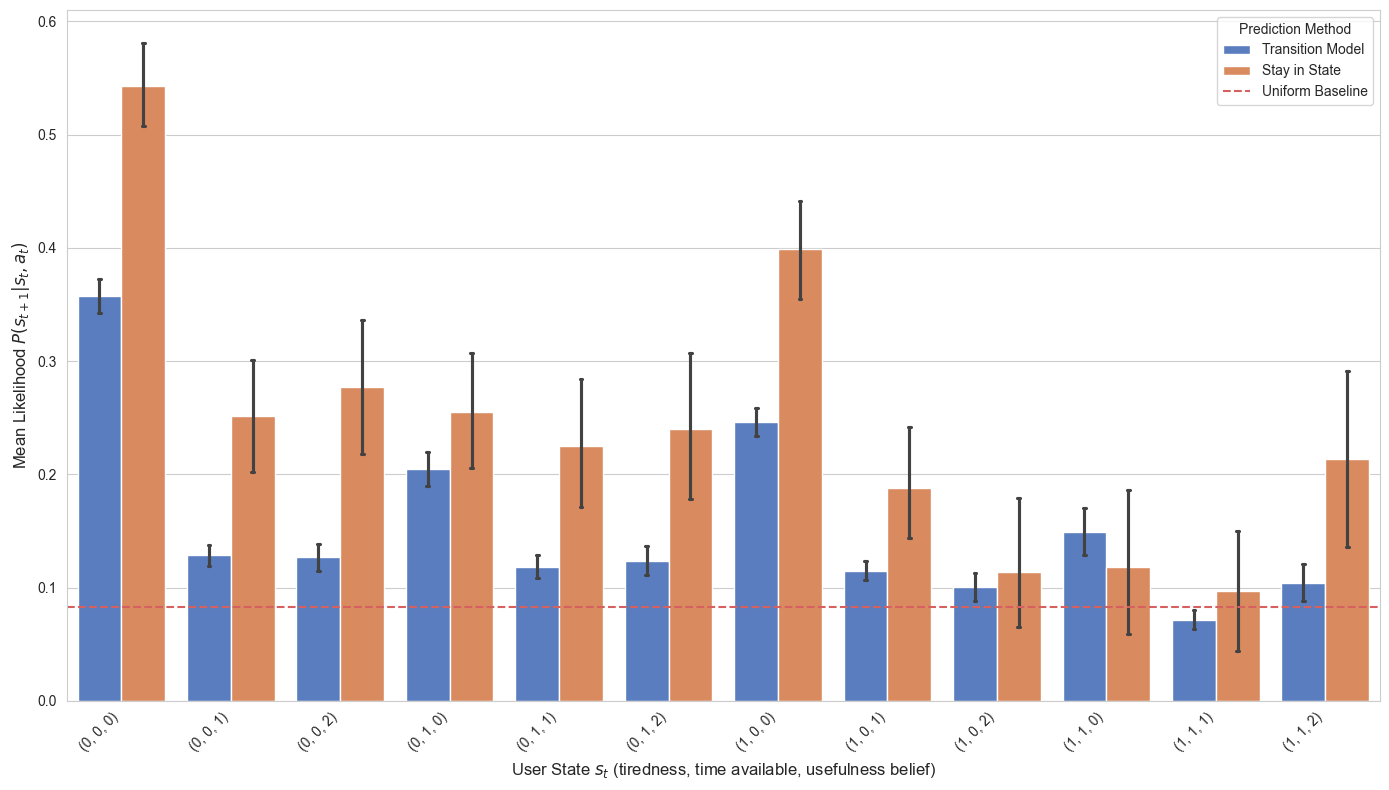

In [29]:
uniform_prob = 1.0 / NUM_USER_STATES

plot_data = combined_results[['s_idx', 'next_state_likelihood', 'equal_state']].copy()
plot_data['State'] = plot_data['s_idx'].apply(lambda x: str(utils.idx_to_user_state(x, NUM_VALS_PER_FEATURE)))

plot_data = plot_data.rename(columns={
    'next_state_likelihood': 'Transition Model',
    'equal_state': 'Stay in State'
})

# sort on s_idx to ensure states are in a logical order
plot_data = plot_data.sort_values('s_idx')

df_melted = plot_data.melt(id_vars=['State'], 
                           value_vars=['Transition Model', 'Stay in State'],
                           var_name='Model', 
                           value_name='Likelihood')

plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

ax = sns.barplot(
    data=df_melted, 
    x='State', 
    y='Likelihood', 
    hue='Model', 
    palette='muted',
    capsize=.05,
    errorbar=('ci', 95)
)

# plt.title('Next State Likelihood by User State', fontsize=16, pad=20)
plt.ylabel('Mean Likelihood $P(s_{t+1} | s_t, a_t)$', fontsize=12)
plt.xlabel('User State $s_t$ (tiredness, time available, usefulness belief)', fontsize=12)

plt.axhline(uniform_prob, color=sns.color_palette("muted")[3], linestyle='--', alpha=1, label='Uniform Baseline')
plt.xticks(rotation=45, ha='right')

plt.legend(title='Prediction Method')
plt.savefig(results_folder + "figures/transition_model_comparison.svg", bbox_inches='tight')
plt.tight_layout()
plt.show()

In [34]:
combined_results['next_state_improvement'] = combined_results['next_state_likelihood'] - combined_results['equal_state']
user_diffs = combined_results.groupby('user_id')['next_state_improvement'].mean().values

ba.paired_t_test(user_diffs)

              mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
improvement -0.111  0.009    -0.130     -0.093      0.000    0.000  2015.271   
effect_size -0.770  0.072    -0.925     -0.641      0.001    0.001  2894.576   

             ess_tail  r_hat  
improvement  2439.923  1.001  
effect_size  2753.544  1.000  
P(improvement > 0): 0.0000
P(Effect Size > 0.1): 1.0000
P(Effect Size > 0.2): 1.0000
P(Effect Size > 0.3): 1.0000


### Completion probabilities evaluation

C:\Users\shirl\AppData\Local\Temp\ipykernel_91152\2309385220.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


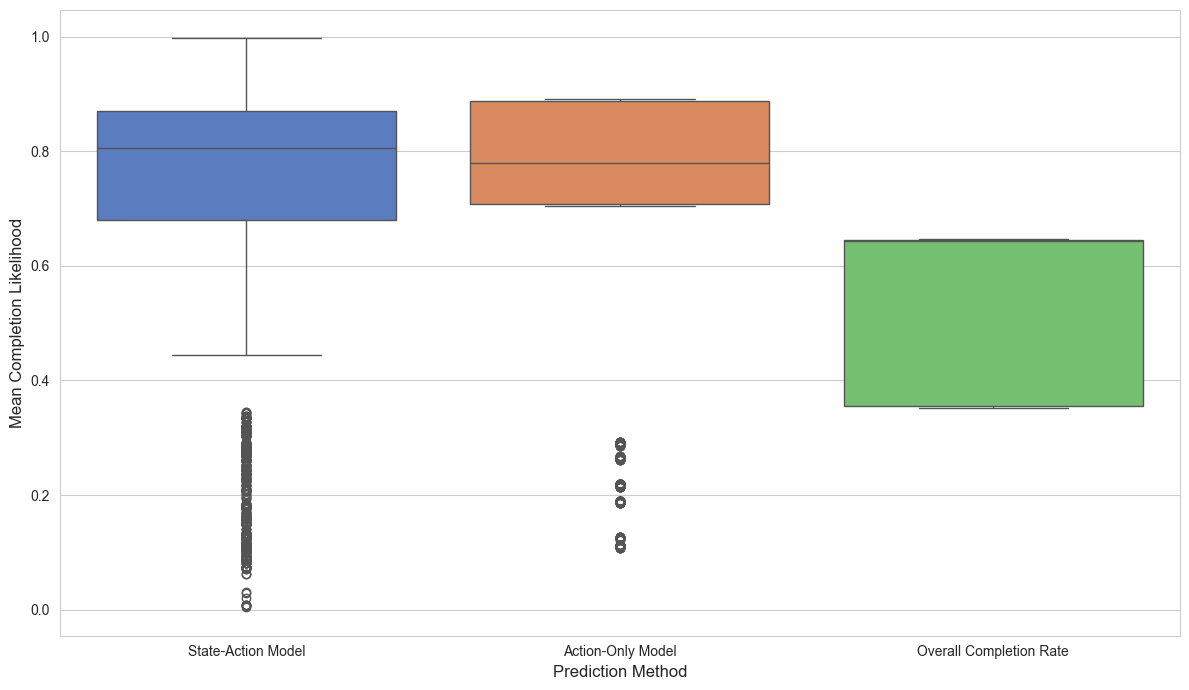


Mean completion likelihoods:
State-Action Model: 0.7007
  95% HDI: [0.0869, 0.9159]
Action-Only Model: 0.6991
  95% HDI: [0.1871, 0.8899]
Overall Completion Rate: 0.5415
  95% HDI: [0.3535, 0.6461]


In [31]:
plot_records = []
model_map = {
    'completion_likelihood': 'State-Action Model',
    'completion_likelihood_action_only': 'Action-Only Model',
    'completion_likelihood_overall': 'Overall Completion Rate'
}

for col, model_name in model_map.items():
    for _, row in combined_results.iterrows():
        plot_records.append({
            'Model': model_name,
            'Likelihood': row[col],
            'Completed': 'Completed' if row['completed'] == 1 else 'Not Completed'
            
        })

plot_df = pd.DataFrame(plot_records)


plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

ax = sns.boxplot(
    data=plot_df, 
    x='Model', 
    y='Likelihood', 
    palette='muted',
    # capsize=.05,
    # errorbar=('ci', 95)
)

# plt.title('Completion Likelihood by Prediction Model', fontsize=14)
plt.ylabel('Mean Completion Likelihood', fontsize=12)
plt.xlabel('Prediction Method', fontsize=12)
plt.savefig(results_folder + "figures/completion_likelihood_comparison_boxplot.svg", bbox_inches='tight')

plt.tight_layout()
plt.show()

print("\nMean completion likelihoods:")
for col, model_name in model_map.items():
    mean_likelihood = combined_results[col].mean()
    print(f"{model_name}: {mean_likelihood:.4f}")
    hdi = az.hdi(np.array(combined_results[col]), hdi_prob=0.95)   
    print(f"  95% HDI: [{hdi[0]:.4f}, {hdi[1]:.4f}]")

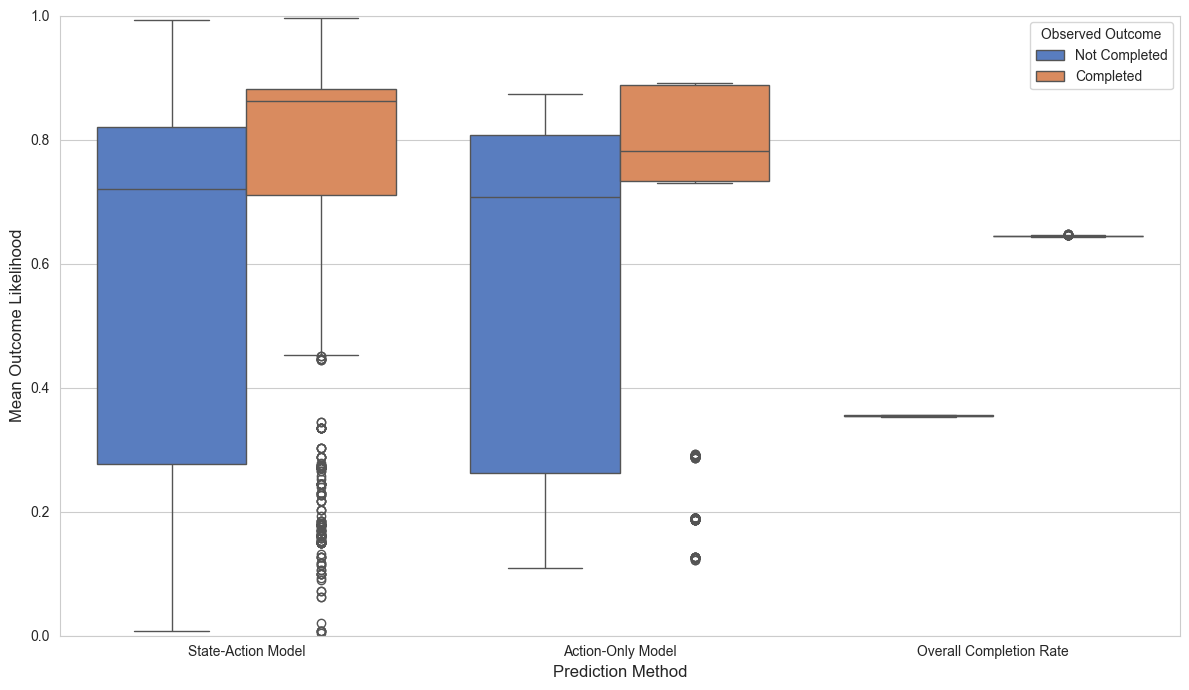

In [32]:
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

ax = sns.boxplot(
    data=plot_df,
    x='Model',
    y='Likelihood',
    hue='Completed',
    palette='muted'
)

# plt.title('Completion Probability Distributions by Outcome', fontsize=14)

plt.ylabel('Mean Outcome Likelihood', fontsize=12)
plt.xlabel('Prediction Method', fontsize=12)

plt.ylim(0, 1)

plt.legend(title='Observed Outcome')
plt.savefig(results_folder + "figures/completion_likelihood_distributions.svg", bbox_inches='tight')
plt.tight_layout()
plt.show()

In [33]:
combined_results['completion_likelihood_diff'] = combined_results['completion_likelihood'] - combined_results['completion_likelihood_action_only']
user_diffs = combined_results.groupby('user_id')['completion_likelihood_diff'].mean().values
ba.paired_t_test(user_diffs)

              mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
improvement  0.001  0.001    -0.002      0.004      0.000    0.000  4912.780   
effect_size  0.050  0.064    -0.071      0.179      0.001    0.001  5067.343   

             ess_tail  r_hat  
improvement  3017.143    1.0  
effect_size  3011.084    1.0  
P(improvement > 0): 0.7847
P(Effect Size > 0.1): 0.2270
P(Effect Size > 0.2): 0.0080
P(Effect Size > 0.3): 0.0000
